# Project description

Sweet Lift Taxi company has collected historical data on taxi orders at airports. To attract more drivers during peak hours, we need to predict the amount of taxi orders for the next hour. Build a model for such a prediction.

The RMSE metric on the test set should not be more than 48.

## Project instructions

1. Download the data and resample it by one hour.
2. Analyze the data.
3. Train different models with different hyperparameters. The test sample should be 10% of the initial dataset. 
4. Test the data using the test sample and provide a conclusion.

## Data description

The data is stored in file `taxi.csv`. The number of orders is in the '*num_orders*' column.

## Preparation

In [105]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [106]:
df = pd.read_csv("taxi.csv", index_col=[0], parse_dates=[0])
print(df.head())
print(df.info())

                     num_orders
datetime                       
2018-03-01 00:00:00           9
2018-03-01 00:10:00          14
2018-03-01 00:20:00          28
2018-03-01 00:30:00          20
2018-03-01 00:40:00          32
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
None


In [107]:
print(df.isna().sum())

num_orders    0
dtype: int64


In [108]:
df = df.resample('1H').sum()

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\1649191478.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.resample('1H').sum()


In [109]:
print(df.describe())

        num_orders
count  4416.000000
mean     84.422781
std      45.023853
min       0.000000
25%      54.000000
50%      78.000000
75%     107.000000
max     462.000000


In [110]:
high_demand = df[df['num_orders'] > 150]
print("Hours with 150+ orders:")
print(high_demand)

# Check if there are patterns
print("\nTime patterns for high demand:")
print(high_demand.index.hour.value_counts().sort_index())

Hours with 150+ orders:
                     num_orders
datetime                       
2018-03-03 00:00:00         163
2018-03-05 01:00:00         176
2018-03-12 01:00:00         153
2018-03-19 01:00:00         163
2018-03-24 01:00:00         182
...                         ...
2018-08-31 18:00:00         207
2018-08-31 20:00:00         154
2018-08-31 21:00:00         159
2018-08-31 22:00:00         223
2018-08-31 23:00:00         205

[358 rows x 1 columns]

Time patterns for high demand:
datetime
0     81
1     30
2     42
3     27
4     17
8      4
9      8
10    14
11     8
12     3
13     2
14     2
15     7
16    28
17    21
18     3
19     3
20     3
21    12
22    17
23    26
Name: count, dtype: int64


The average taxi demand is approximately 84 orders per hour, with most hours ranging between 54 and 107 orders. However, some hours exceed 150 orders, indicating periods of unusually high demand. Analysis of these high-demand hours shows that they occur most frequently around midnight and the early morning hours (00:00–03:00), with additional spikes appearing in the late afternoon and evening (16:00–17:00 and around 23:00). This suggests that taxi demand follows a strong time-of-day pattern, making features such as the hour of the day important predictors for forecasting models.

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\3135838894.py:1: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df.resample('10T').sum().plot(figsize=(12,6))


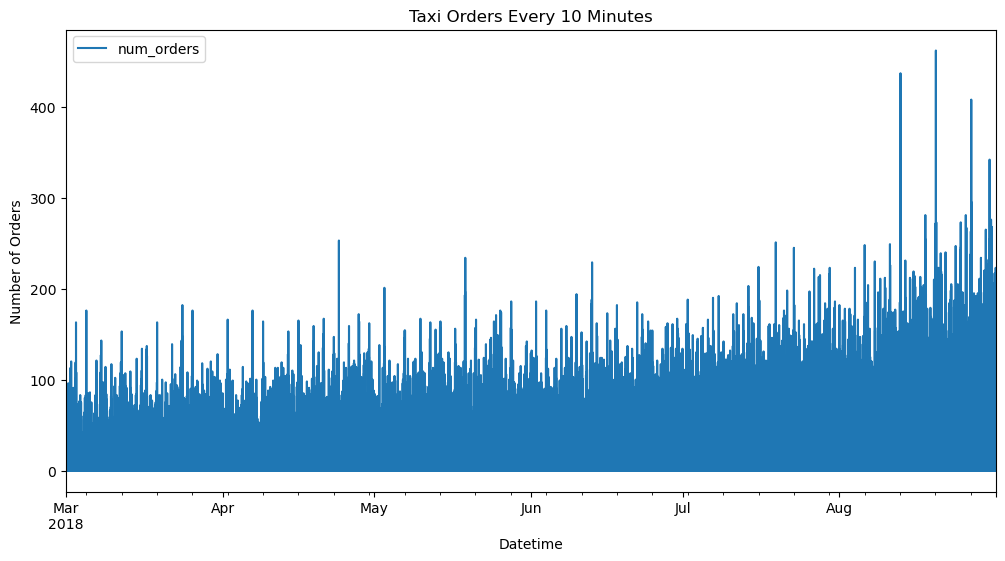

In [111]:
df.resample('10T').sum().plot(figsize=(12,6))

plt.title("Taxi Orders Every 10 Minutes")
plt.ylabel("Number of Orders")
plt.xlabel("Datetime")

plt.show()

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\635338478.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.resample('1H').sum().plot(figsize=(12,6))


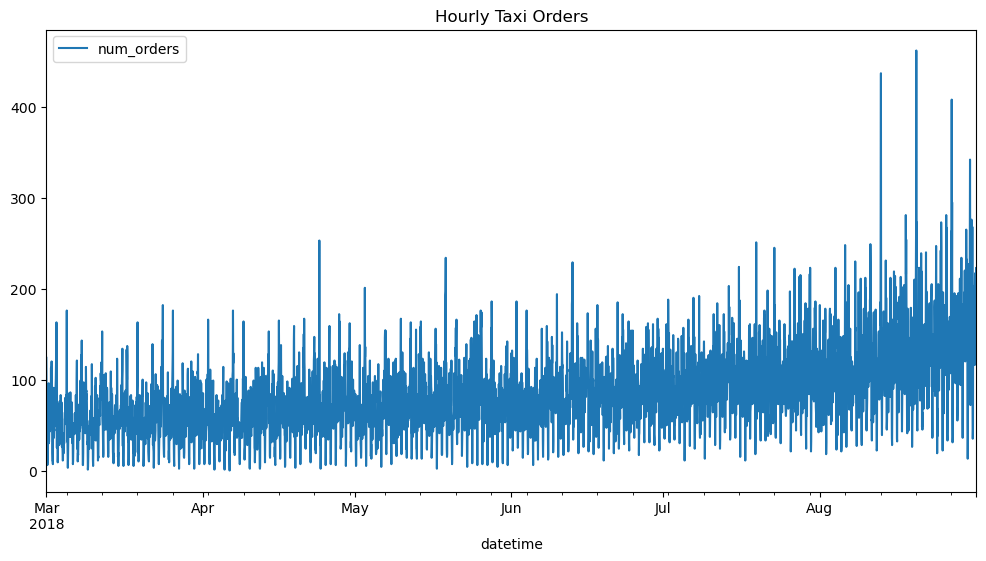

In [112]:
df.resample('1H').sum().plot(figsize=(12,6))
plt.title("Hourly Taxi Orders")
plt.show()

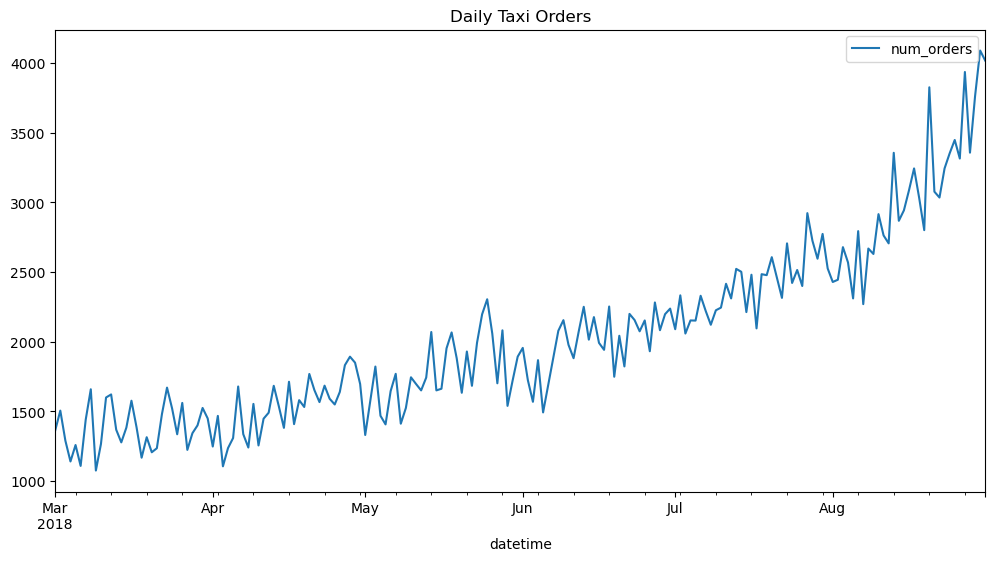

In [113]:
df.resample('1D').sum().plot(figsize=(12,6))
plt.title("Daily Taxi Orders")
plt.show()

## Analysis

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\3502673642.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  decomposed = seasonal_decompose(df.resample('1H').sum())


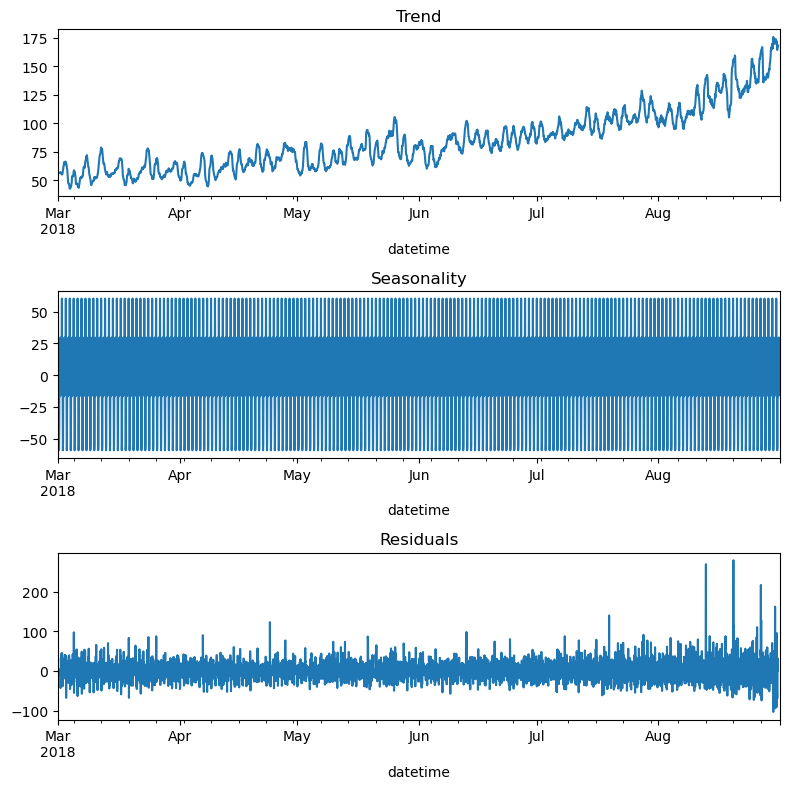

In [114]:
decomposed = seasonal_decompose(df.resample('1H').sum())
plt.figure(figsize=(8, 8))

plt.subplot(311)
decomposed.trend.plot(ax=plt.gca())
plt.title('Trend')
plt.subplot(312)
decomposed.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.subplot(313)
decomposed.resid.plot(ax=plt.gca())
plt.title('Residuals')

plt.tight_layout() 


The trend shows a gradual increase in taxi orders over time, while the residuals represent random fluctuations and unexpected spikes that are not explained by the trend or seasonal patterns, and because the hourly seasonality repeats very frequently it is difficult to see clearly across the full dataset, so we examine a one-week period to better observe the seasonal pattern.

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\3025470911.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  decomposed_1 = seasonal_decompose(df.resample('1H').sum().iloc[:168])


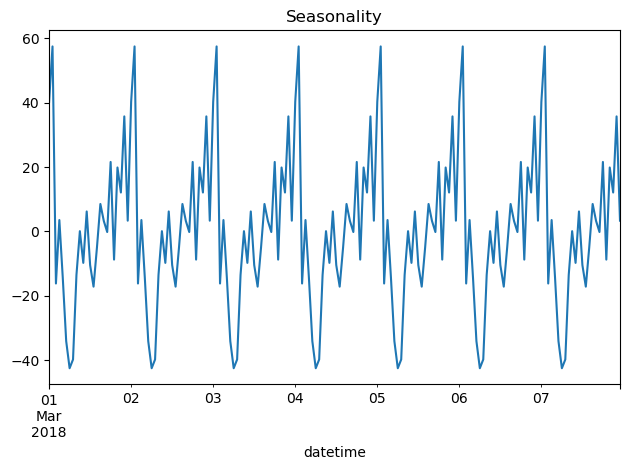

In [115]:
decomposed_1 = seasonal_decompose(df.resample('1H').sum().iloc[:168])
decomposed_1.seasonal.plot(ax=plt.gca())
plt.title('Seasonality')
plt.tight_layout() 


The seasonal decomposition reveals clear hourly patterns: taxi demand peaks in the evening hours and declines during early morning hours when fewer people travel.

## Feature Engineering for Time Series

Before training machine learning models, the time-series data needs to be transformed into a tabular format with meaningful features. The following function creates additional variables from the datetime index and from past values of the target variable.

First, calendar-based features such as year, month, day, and day of the week are extracted from the datetime index. These features help the model capture seasonal patterns in taxi demand.

Next, lag features are generated. Lag variables represent the number of taxi orders in previous time steps, allowing the model to learn how past demand influences future demand.

Finally, a rolling mean feature is calculated to capture short-term trends by averaging the number of orders over a specified window.

In [116]:

def make_features(df, max_lag, rolling_mean_size):
    df['year'] = df.index.year
    df['month'] = df.index.month
    df['day'] = df.index.day
    df['dayofweek'] = df.index.dayofweek
    df['hour'] = df.index.hour
    
    for lag in range(1, max_lag + 1):
        df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
    df['rolling_mean'] = df['num_orders'].shift().rolling(rolling_mean_size).mean()
    

make_features(df, 168, 24)
print(df.head())



                     num_orders  year  month  day  dayofweek  hour  lag_1  \
datetime                                                                    
2018-03-01 00:00:00         124  2018      3    1          3     0    NaN   
2018-03-01 01:00:00          85  2018      3    1          3     1  124.0   
2018-03-01 02:00:00          71  2018      3    1          3     2   85.0   
2018-03-01 03:00:00          66  2018      3    1          3     3   71.0   
2018-03-01 04:00:00          43  2018      3    1          3     4   66.0   

                     lag_2  lag_3  lag_4  ...  lag_160  lag_161  lag_162  \
datetime                                  ...                              
2018-03-01 00:00:00    NaN    NaN    NaN  ...      NaN      NaN      NaN   
2018-03-01 01:00:00    NaN    NaN    NaN  ...      NaN      NaN      NaN   
2018-03-01 02:00:00  124.0    NaN    NaN  ...      NaN      NaN      NaN   
2018-03-01 03:00:00   85.0  124.0    NaN  ...      NaN      NaN      NaN   
2018

C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\2234293749.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\2234293749.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['lag_{}'.format(lag)] = df['num_orders'].shift(lag)
C:\Users\mmend\AppData\Local\Temp\ipykernel_17960\2234293749.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poo

In [117]:
df = df.dropna()
print(df.head())

                     num_orders  year  month  day  dayofweek  hour  lag_1  \
datetime                                                                    
2018-03-08 00:00:00         143  2018      3    8          3     0   94.0   
2018-03-08 01:00:00          78  2018      3    8          3     1  143.0   
2018-03-08 02:00:00          65  2018      3    8          3     2   78.0   
2018-03-08 03:00:00          68  2018      3    8          3     3   65.0   
2018-03-08 04:00:00          60  2018      3    8          3     4   68.0   

                     lag_2  lag_3  lag_4  ...  lag_160  lag_161  lag_162  \
datetime                                  ...                              
2018-03-08 00:00:00  127.0  108.0   76.0  ...     34.0     15.0     12.0   
2018-03-08 01:00:00   94.0  127.0  108.0  ...     69.0     34.0     15.0   
2018-03-08 02:00:00  143.0   94.0  127.0  ...     64.0     69.0     34.0   
2018-03-08 03:00:00   78.0  143.0   94.0  ...     96.0     64.0     69.0   
2018

In [118]:

df_temp, df_test = train_test_split(df, test_size=0.1, shuffle=False)
df_train, df_valid = train_test_split(df_temp, test_size=0.111, shuffle=False)
print("Train size:", len(df_train))
print("Validation size:", len(df_valid))
print("Test size:", len(df_test))


Train size: 3398
Validation size: 425
Test size: 425


In [119]:
features_train = df_train.drop('num_orders', axis=1)
target_train = df_train['num_orders']

features_valid = df_valid.drop('num_orders', axis=1)
target_valid = df_valid['num_orders']

features_test = df_test.drop('num_orders', axis=1)
target_test = df_test['num_orders']
print("Train:", features_train.shape, target_train.shape)
print("Validation:", features_valid.shape, target_valid.shape)
print("Test:", features_test.shape, target_test.shape)


Train: (3398, 174) (3398,)
Validation: (425, 174) (425,)
Test: (425, 174) (425,)


In [120]:


lr_model = LinearRegression()
lr_model.fit(features_train, target_train)

predicted_values = lr_model.predict(features_valid)

# Validation metrics
lr_rmse = np.sqrt(mean_squared_error(target_valid, predicted_values))
lr_mae = mean_absolute_error(target_valid, predicted_values)
lr_r2 = r2_score(target_valid, predicted_values)

# Training metrics
train_predictions = lr_model.predict(features_train)

train_rmse = np.sqrt(mean_squared_error(target_train, train_predictions))
train_mae = mean_absolute_error(target_train, train_predictions)
train_r2 = r2_score(target_train, train_predictions)

print("Training RMSE:", train_rmse)
print("Training MAE:", train_mae)
print("Training R²:", train_r2)

print("Validation RMSE:", lr_rmse)
print("Validation MAE:", lr_mae)
print("Validation R²:", lr_r2)





Training RMSE: 19.241950304046824
Training MAE: 14.615636171358329
Training R²: 0.7119463114922335
Validation RMSE: 29.20623280949691
Validation MAE: 20.763748174621096
Validation R²: 0.6054609976316558


In [121]:



random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=12345
)

random_forest.fit(features_train, target_train)

predicted_valid = random_forest.predict(features_valid)

rf_rmse = np.sqrt(mean_squared_error(target_valid, predicted_valid))
rf_mae = mean_absolute_error(target_valid, predicted_valid)
rf_r2 = r2_score(target_valid, predicted_valid)

print("Random Forest Results:")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R²: {rf_r2:.2f}")


Random Forest Results:
RMSE: 30.63
MAE: 20.73
R²: 0.57


In [122]:


decision_tree = DecisionTreeRegressor(random_state=12345)

decision_tree.fit(features_train, target_train)

predicted_valid = decision_tree.predict(features_valid)

dt_rmse = np.sqrt(mean_squared_error(target_valid, predicted_valid))
dt_mae = mean_absolute_error(target_valid, predicted_valid)
dt_r2 = r2_score(target_valid, predicted_valid)

print("Decision Tree Results:")
print(f"RMSE: {dt_rmse:.2f}")
print(f"MAE: {dt_mae:.2f}")
print(f"R²: {dt_r2:.2f}")


Decision Tree Results:
RMSE: 42.37
MAE: 31.11
R²: 0.17


In [123]:
# best_rmse = float("inf")
# best_params = {}

# for lr in [0.01, 0.05, 0.1]:
#     for leaves in [31, 63, 127, 255]:
#         for n_est in [100, 300, 500]:
            
#             model = LGBMRegressor(
#                 learning_rate=lr,
#                 num_leaves=leaves,
#                 n_estimators=n_est,
#                 random_state=12345
#             )
            
#             model.fit(features_train, target_train)
#             preds = model.predict(features_valid)
            
#             rmse = np.sqrt(mean_squared_error(target_valid, preds))
            
#             if rmse < best_rmse:
#                 best_rmse = rmse
#                 best_params = {
#                     "learning_rate": lr,
#                     "num_leaves": leaves,
#                     "n_estimators": n_est
#                 }


# print("Best Paramaters:", best_params)

LightGBM showed the best overall performance among the tested models, indicating its ability to capture complex patterns in the data. To further improve results, hyperparameter tuning was conducted with the goal of minimizing error metrics and enhancing the model’s predictive accuracy

In [124]:
LGBMR = LGBMRegressor(
    learning_rate=0.1,
    num_leaves=255,
    n_estimators=500
)

LGBMR.fit(features_train, target_train)

predicted_valid = LGBMR.predict(features_valid)

lgbm_rmse = np.sqrt(mean_squared_error(target_valid, predicted_valid))
lgbm_mae = mean_absolute_error(target_valid, predicted_valid)
lgbm_r2 = r2_score(target_valid, predicted_valid)

print("LightGBM Results:")
print(f"RMSE: {lgbm_rmse:.2f}")
print(f"MAE: {lgbm_mae:.2f}")
print(f"R²: {lgbm_r2:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005721 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 29704
[LightGBM] [Info] Number of data points in the train set: 3398, number of used features: 173
[LightGBM] [Info] Start training from score 75.588582
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [125]:


cat_model = CatBoostRegressor(
    learning_rate=0.1,
    iterations=500,
    depth=8,
    verbose=0
)

cat_model.fit(features_train, target_train)

predicted_valid = cat_model.predict(features_valid)

cat_rmse = np.sqrt(mean_squared_error(target_valid, predicted_valid))
cat_mae = mean_absolute_error(target_valid, predicted_valid)
cat_r2 = r2_score(target_valid, predicted_valid)

print("CatBoost Results:")
print(f"RMSE: {cat_rmse:.2f}")
print(f"MAE: {cat_mae:.2f}")
print(f"R²: {cat_r2:.2f}")

CatBoost Results:
RMSE: 31.01
MAE: 21.13
R²: 0.56


In [126]:

xgb_model = XGBRegressor(
    learning_rate=0.1,
    n_estimators=500,
    max_depth=8,
    random_state=12345
)

xgb_model.fit(features_train, target_train)

predicted_valid = xgb_model.predict(features_valid)

xgb_rmse = np.sqrt(mean_squared_error(target_valid, predicted_valid))
xgb_mae = mean_absolute_error(target_valid, predicted_valid)
xgb_r2 = r2_score(target_valid, predicted_valid)

print("XGBoost Results:")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAE: {xgb_mae:.2f}")
print(f"R²: {xgb_r2:.2f}")

XGBoost Results:
RMSE: 31.36
MAE: 21.34
R²: 0.55


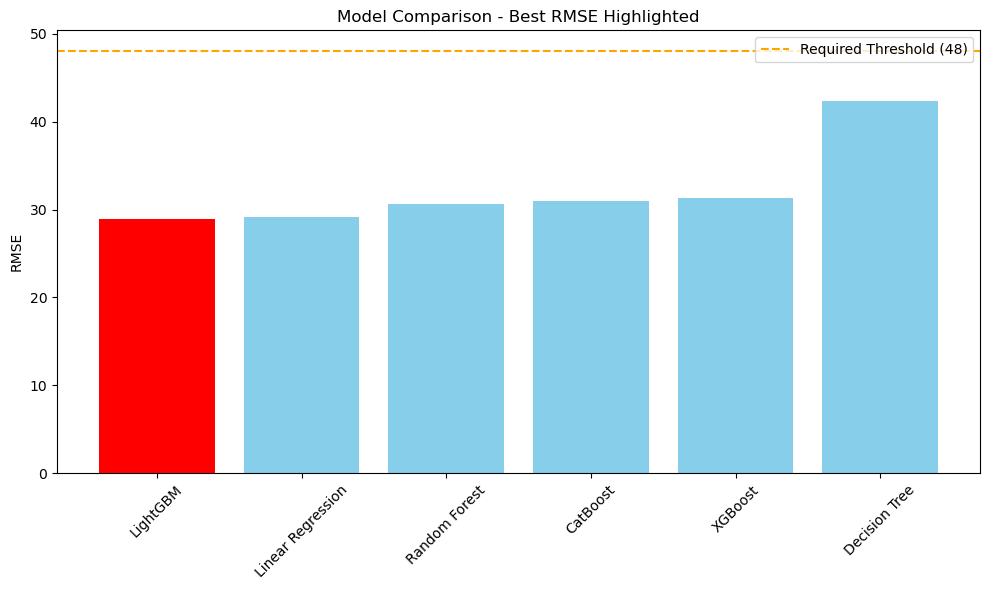

In [127]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "LightGBM",
        "CatBoost",
        "XGBoost"
    ],
    "RMSE": [
        lr_rmse,
        dt_rmse,
        rf_rmse,
        lgbm_rmse,
        cat_rmse,
        xgb_rmse
    ],
    "MAE": [
        lr_mae,
        dt_mae,
        rf_mae,
        lgbm_mae,
        cat_mae,
        xgb_mae
    ],
    "R2": [
        lr_r2,
        dt_r2,
        rf_r2,
        lgbm_r2,
        cat_r2,
        xgb_r2
    ]
})
results_df = results.sort_values("RMSE")
plt.figure(figsize=(10, 6))
colors = ['red' if rmse == results_df["RMSE"].min() else 'skyblue' 
          for rmse in results_df["RMSE"]]
plt.bar(results_df["Model"], results_df["RMSE"], color=colors)
plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Model Comparison - Best RMSE Highlighted")
plt.axhline(y=48, color='orange', linestyle='--', label='Required Threshold (48)')
plt.legend()
plt.tight_layout()
plt.show()

In [128]:
print("\n📊 COMPLETE RANKING:")
for i, row in results_df.iterrows():
    print(f"{results_df.index.get_loc(i)+1}. {row['Model']}: RMSE = {row['RMSE']:.2f}")


📊 COMPLETE RANKING:
1. LightGBM: RMSE = 28.89
2. Linear Regression: RMSE = 29.21
3. Random Forest: RMSE = 30.63
4. CatBoost: RMSE = 31.01
5. XGBoost: RMSE = 31.36
6. Decision Tree: RMSE = 42.37


## Testing

In [129]:
df_train_final = pd.concat([df_train, df_valid])
features_train_final = df_train_final.drop('num_orders', axis=1)
target_train_final = df_train_final['num_orders']

features_test = df_test.drop('num_orders', axis=1)
target_test = df_test['num_orders']

In [130]:
best_model = LGBMRegressor(
    learning_rate=0.1,
    num_leaves=255,
    n_estimators=500
)
best_model.fit(features_train_final, target_train_final)
predicted_test = best_model.predict(features_test)

test_rmse = np.sqrt(mean_squared_error(target_test, predicted_test))
test_mae = mean_absolute_error(target_test, predicted_test)
test_r2 = r2_score(target_test, predicted_test)

print("Test Results:")
print(f"RMSE: {test_rmse:.2f}")
print(f"MAE: {test_mae:.2f}")
print(f"R²: {test_r2:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005126 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 31626
[LightGBM] [Info] Number of data points in the train set: 3823, number of used features: 173
[LightGBM] [Info] Start training from score 79.561601
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

## Conclusion:
In this project, historical taxi order data was analyzed to build a model capable of predicting future demand. The data was resampled to hourly intervals and explored to identify trends and seasonal patterns. Exploratory analysis revealed clear temporal structure in taxi demand, with fluctuations depending on the time of day and day of the week. To capture these patterns, the time series data was transformed into tabular format by creating additional features such as calendar variables, lag features representing previous taxi orders, and a rolling mean to reflect short-term demand trends.

Several regression models were trained and evaluated, including Linear Regression, Decision Tree, Random Forest, LightGBM, CatBoost, and XGBoost. The models were compared using the RMSE metric on the validation dataset. Among all models, LightGBM achieved the best performance with an RMSE of 28.89, outperforming Linear Regression (29.21) and other ensemble methods. This improvement was achieved after hyperparameter tuning, where the model was optimized using learning_rate=0.1, num_leaves=255, and n_estimators=500. These parameters allowed the model to better capture complex nonlinear relationships and interactions in the data.

The final ranking of models based on validation RMSE was as follows: LightGBM (28.89), Linear Regression (29.21), Random Forest (30.63), CatBoost (31.01), XGBoost (31.36), and Decision Tree (42.37). This demonstrates that while simpler models performed reasonably well due to effective feature engineering, the tuned LightGBM model was able to achieve the highest predictive accuracy.

On the test dataset, the final LightGBM model achieved an RMSE of 38.93, MAE of 29.24, and an R² score of 0.56. Although the test error is higher than the validation score, the results indicate that the model generalizes reasonably well to unseen data. Overall, this project shows that combining time-based feature engineering with advanced ensemble methods such as LightGBM can effectively forecast taxi demand and capture both linear and nonlinear patterns in the data.

# Review checklist

- [x]  Jupyter Notebook is open
- [ ]  The code is error-free
- [ ]  The cells with the code have been arranged in order of execution
- [ ]  The data has been downloaded and prepared
- [ ]  The data has been analyzed
- [ ]  The model has been trained and hyperparameters have been selected
- [ ]  The models have been evaluated. Conclusion has been provided
- [ ] *RMSE* for the test set is not more than 48